In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Define the local path to your uploaded file
# Typically, this will be 'filename.csv' if uploaded to the main folder
file_path = 'C:/Users/lenovo/Downloads/tuberculosis-treatment-success-rate-in-new-and-relapsed-cases.csv'

# Load the dataset directly from the local environment [2]
df = pd.read_csv(file_path)

# Verify the ingestion by viewing the schema and first 5 entries
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5297 entries, 0 to 5296
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Entity                 5297 non-null   object
 1   Code                   5297 non-null   object
 2   Year                   5297 non-null   int64 
 3   New and relapse cases  5297 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 165.7+ KB
None


,Entity,Code,Year,New and relapse cases
0,Afghanistan,AFG,1997,45
1,Afghanistan,AFG,1998,33
2,Afghanistan,AFG,1999,86
3,Afghanistan,AFG,2000,85
4,Afghanistan,AFG,2001,84


In [ ]:
import pandas as pd

# 1. Load the data
file_name = 'tuberculosis-treatment-success-rate-in-new-and-relapsed-cases.csv'
df = pd.read_csv(file_name)

# 2. Rename columns immediately for easier coding
# This maps that long name to 'Value' so your logic remains simple
df = df.rename(columns={'New and relapse cases': 'Value'})

print(f"Dataset Size: {df.shape}")
print("\n--- Column Info ---")
print(df.dtypes)

# 3. Handle Missing Values and Duplicates
# We use 'Value' now because we renamed it above
df_cleaned = df.dropna(subset=['Value'])
duplicate_count = df_cleaned.duplicated().sum()
print(f"\nDuplicates found: {duplicate_count}")
df_cleaned = df_cleaned.drop_duplicates()

# 4. Filter for a specific year (Fixing the SyntaxError)
# We ensure df_2022 is a DataFrame by using the correct filtering syntax
df_2022 = df_cleaned[df_cleaned['Year'] == 2022].copy()

# 5. Convert Data Types (Fixing the TypeError)
# We target specific columns to avoid errors with text columns
df_2022['Year'] = df_2022['Year'].astype(int)
df_2022['Value'] = df_2022['Value'].astype(float)

print("\n--- Final Cleaned Preview (2022 Data) ---")
print(df_2022.head())

Dataset Size: (5297, 4)

--- Column Info ---
Entity    object
Code      object
Year       int64
Value      int64
dtype: object

Duplicates found: 0

--- Final Cleaned Preview (2022 Data) ---
          Entity Code  Year  Value
25   Afghanistan  AFG  2022   95.0
48       Albania  ALB  2022   89.0
76       Algeria  DZA  2022   90.0
118      Andorra  AND  2022  100.0
142       Angola  AGO  2022   65.0


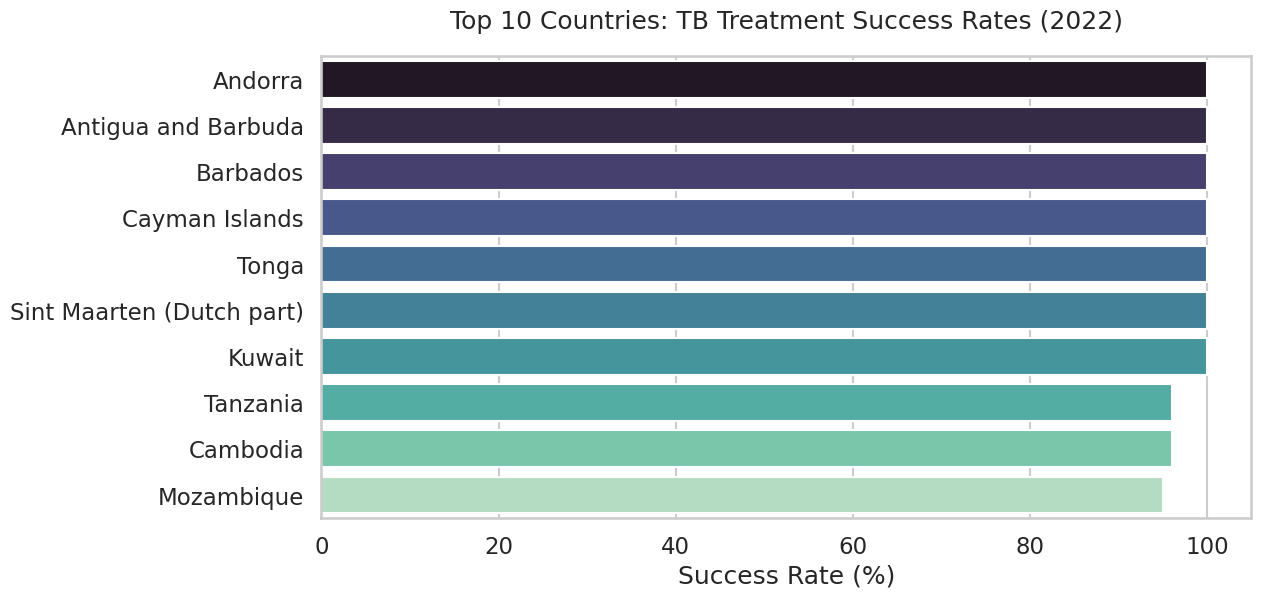

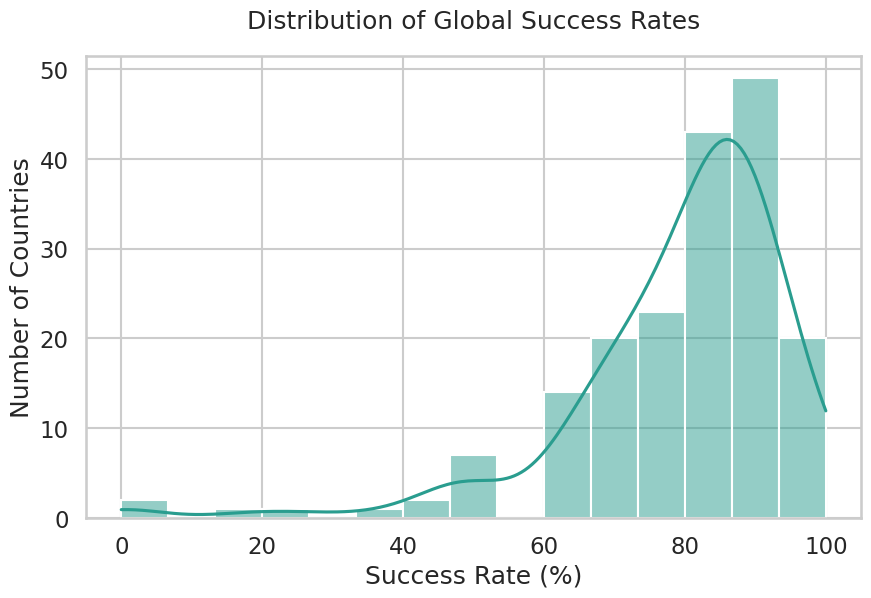

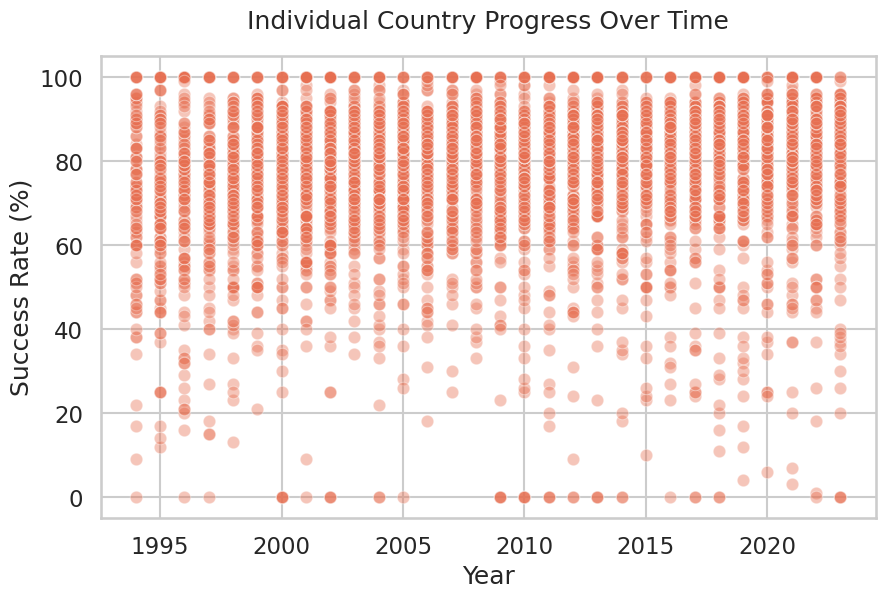

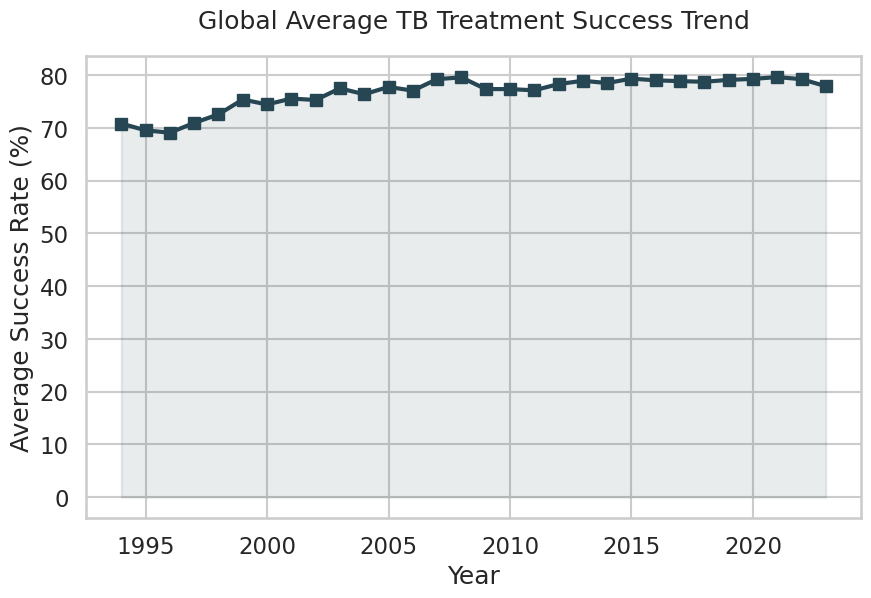

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style for a university presentation
sns.set_context("talk")
sns.set_style("whitegrid")

# --- 1. BAR CHART: Who is leading? ---
plt.figure(figsize=(12, 6))
top_countries = df_2022.sort_values('Value', ascending=False).head(10)
sns.barplot(data=top_countries, x='Value', y='Entity', hue='Entity', palette='mako', legend=False)
plt.title('Top 10 Countries: TB Treatment Success Rates (2022)', pad=20)
plt.xlabel('Success Rate (%)')
plt.ylabel('')
plt.show()

# --- 2. HISTOGRAM: Is the world doing well? ---
plt.figure(figsize=(10, 6))
sns.histplot(df_2022['Value'], bins=15, kde=True, color='#2a9d8f')
plt.title('Distribution of Global Success Rates', pad=20)
plt.xlabel('Success Rate (%)')
plt.ylabel('Number of Countries')
plt.show()

# --- 3. SCATTER PLOT: Are we improving over time? ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='Year', y='Value', alpha=0.4, color='#e76f51')
plt.title('Individual Country Progress Over Time', pad=20)
plt.xlabel('Year')
plt.ylabel('Success Rate (%)')
plt.show()

# --- 4. LINE PLOT: The "Big Picture" Trend ---
plt.figure(figsize=(10, 6))
yearly_avg = df_cleaned.groupby('Year')['Value'].mean()
plt.plot(yearly_avg.index, yearly_avg.values, marker='s', color='#264653', linewidth=3)
plt.fill_between(yearly_avg.index, yearly_avg.values, alpha=0.1, color='#264653')
plt.title('Global Average TB Treatment Success Trend', pad=20)
plt.xlabel('Year')
plt.ylabel('Average Success Rate (%)')
plt.show()

In [ ]:
# Select the data column we want to analyze
data = df_2022['Value']

# 1. Compute Central Tendency
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]  # .mode() returns a Series, we take the first value

# 2. Compute Dispersion (Spread)
variance_val = data.var()
std_dev_val = data.std()

# Display the results
print("--- Descriptive Statistics (2022) ---")
print(f"Mean (Average):       {mean_val:.2f}%")
print(f"Median (Middle):      {median_val:.2f}%")
print(f"Mode (Most Common):   {mode_val:.2f}%")
print(f"Variance:             {variance_val:.2f}")
print(f"Standard Deviation:   {std_dev_val:.2f}%")

--- Descriptive Statistics (2022) ---
Mean (Average):       79.22%
Median (Middle):      84.00%
Mode (Most Common):   87.00%
Variance:             254.48
Standard Deviation:   15.95%


In [ ]:
# We use Stratified Sampling based on the 'Year' column
# This ensures each year is fairly represented in our 10% sample
df_sample = df_cleaned.groupby('Year', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))

print(f"Original Dataset Size: {len(df_cleaned)}")
print(f"Sampled Dataset Size: {len(df_sample)}")
print("\n--- Sample Preview ---")
print(df_sample.head())

Original Dataset Size: 5297
Sampled Dataset Size: 528

--- Sample Preview ---
         Entity Code  Year  Value
1879  Guatemala  GTM  1994     62
3622      Palau  PLW  1994     64
3593   Pakistan  PAK  1994     69
2990     Mexico  MEX  1994     63
2664      Libya  LBY  1994     64


/tmp/ipykernel_5031/594162408.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_cleaned.groupby('Year', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))


In [ ]:
import numpy as np
from scipy import stats

# 1. Estimate the Parameter (Sample Mean)
sample_mean = df_2022['Value'].mean()
sample_size = len(df_2022['Value'])
sample_std_err = stats.sem(df_2022['Value']) # Standard Error

# 2. Construct a 95% Confidence Interval (CI)
# We use the t-distribution because we are estimating from a sample
confidence_level = 0.95
degrees_freedom = sample_size - 1

ci_lower, ci_upper = stats.t.interval(confidence_level,
                                      degrees_freedom,
                                      loc=sample_mean,
                                      scale=sample_std_err)

print(f"Sample Mean Estimate: {sample_mean:.2f}%")
print(f"95% Confidence Interval: ({ci_lower:.2f}%, {ci_upper:.2f}%)")

Sample Mean Estimate: 79.22%
95% Confidence Interval: (76.89%, 81.55%)
